### This notebook compute "E8. Number of homes with public lighting" indicator for the 27 basins of IKI Project

Spanish: Número de viviendas con alumbrado eléctrico por red pública

**Created:** 8/4/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/5/2026 by Sophia (sbakar@rti.org   )

**Status:** Complete and loaded into SQLite database for the baseline and first future scenario.

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure
 
**Inputs:**   Used data from INEI (https://censos2017.inei.gob.pe/pubinei/index.asp) using the question 'La vivienda tiene alumbrado electrico por red publica'

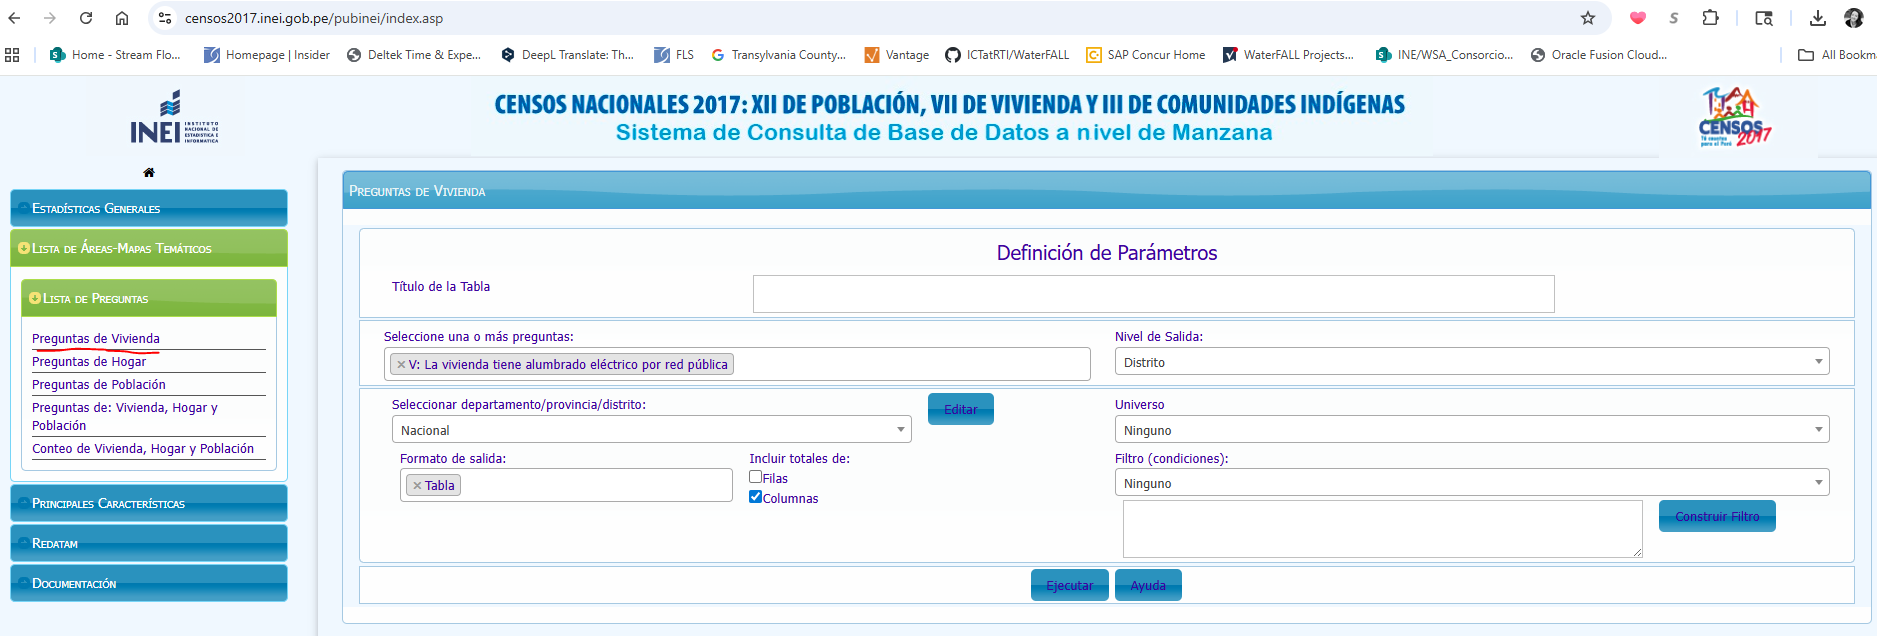

Scroll to bottom of table and click 'Descargar en formato Excel'
 
**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib  

**Assumptions:** Given district-level data, there are some implied assumptions in associating with COMIDs. This is attempted to be mitigated with the weighted method. Rounding to nearest whole number. 

**N/A Handling:** All COMIDs that do not have homes with public lighting should be NaN.
 
**Future work:** Find higher resolution data that could be used and associated with the COMIDs. Determine assumption for areas outside of Peru: 
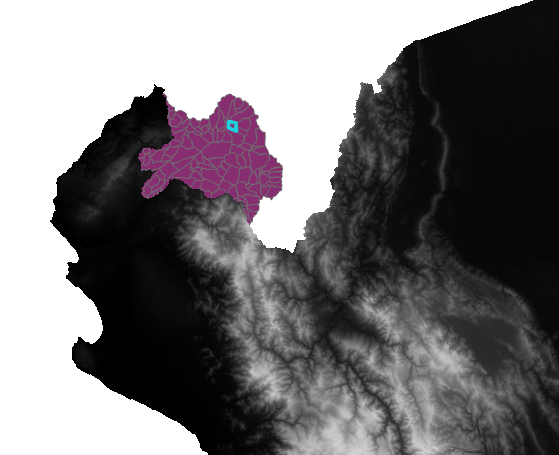
 
**Notes:** Information also exists at nivel de manzanas (INEI - REDATAM CENSOS 2017 - https://censos2017.inei.gob.pe/pubinei/index.asp), however we could not find geospatial information for manzanas so we did not use this higher resolution route.   

General Methodology:  
1. Determines proportionate area of each district within each COMID.  
2. Calculates the weighted lighting value.  
3. Applies proportionate values to determine lighting values for COMIDs. 
4. Replaces values for COMIDs with no lighting values with NaN; rounds values to whole numbers.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 208 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#district_area = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv'
district_area = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\COMID_District_Fractions.csv"

# number_of_homes_lighting = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Exposicion/E7_Number of homes with public lighting/'
number_of_homes_lighting = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\E7_Number of homes with public lighting/"

In [5]:
# read in input data
#Define District_within_COMID fractions csv - this allows for a weighted method to be used for assigning district level data to subbasins
district_area_within_COMID= pd.read_csv(district_area)

#Define subbasin shapefile
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in excel
lighting_input_file= pd.read_excel(number_of_homes_lighting + 'Alumbrado_electrico_red_publica_distrito_2017.xlsx', skiprows=5)

In [6]:
# check district codes to ensure they are matching between the district area by COMID and the INEI dataset (for QC purposes)
# District-area file
district_numeric = pd.to_numeric(
    district_area_within_COMID['DISTRICT'],
    errors='coerce'
)

print("District area file:")
print("  Min DISTRICT:", int(district_numeric.min()))
print("  Max DISTRICT:", int(district_numeric.max()))
print("  Unique districts:", district_numeric.nunique())

# Lighting file
codigo_numeric = pd.to_numeric(
    lighting_input_file['Código'],
    errors='coerce'
)

print("\nLighting file:")
print("  Min Código:", int(codigo_numeric.min()))
print("  Max Código:", int(codigo_numeric.max()))
print("  Unique districts:", codigo_numeric.nunique())

# Overlap check
district_set = set(district_numeric.dropna().astype(int))
lighting_set = set(codigo_numeric.dropna().astype(int))

print("\nOverlap check:")
print("  Matching districts:", len(district_set & lighting_set))
print("  Districts only in area file:", len(district_set - lighting_set))
print("  Districts only in lighting file:", len(lighting_set - district_set))

District area file:
  Min DISTRICT: 10103
  Max DISTRICT: 250401
  Unique districts: 1299

Lighting file:
  Min Código: 10101
  Max Código: 250401
  Unique districts: 1874

Overlap check:
  Matching districts: 1293
  Districts only in area file: 6
  Districts only in lighting file: 581


In [7]:
# format input data for processing
# Clean lighting data
lighting_df = lighting_input_file.rename(columns={
    'Código':'DISTRICT',
    'Sí tiene alumbrado eléctrico': 'Lighting'
})
lighting_df['DISTRICT'] = pd.to_numeric(lighting_df['DISTRICT'], errors='coerce')
lighting_df['Lighting'] = pd.to_numeric(lighting_df['Lighting'], errors='coerce')
lighting_df = lighting_df.dropna(subset=['DISTRICT', 'Lighting'])
lighting_df['DISTRICT'] = lighting_df['DISTRICT'].astype(int)
lighting_df = lighting_df[['DISTRICT','Lighting']]

# Clean district fractions
district_fractions_df = district_area_within_COMID.copy()
district_fractions_df['DISTRICT'] = pd.to_numeric(district_fractions_df['DISTRICT'], errors='coerce')
district_fractions_df = district_fractions_df.dropna(subset=['DISTRICT'])
district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(int)

In [8]:
#WEIGHTED METHOD FUNCTION 
# For each COMID, calculate proportionate lighting values based on district area fractions
#could amplify this fraction so it could read in any value by IDDIST 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """

    # Merge district fractions with indicator values
    merged = district_fractions_df.merge(
        value_df, 
        on='DISTRICT',
        how='left',
        validate='many_to_one'  # each district has one indicator value
    )
    
    # Calculate weighted indicator
    merged['weighted_value'] = merged[column_name] * merged['district_area_within_COMID_fraction']
    
    # Aggregate by COMID
    proportionate_df = (
        merged.groupby('COMID', as_index=False)['weighted_value']
              .sum(min_count=1)  # keeps NaN if all values are NaN
              .rename(columns={'weighted_value':'proportionate_indicator_value'})
    )
    
    # Ensure all COMIDs are included
    proportionate_df = pd.DataFrame({'COMID': comid_list}).merge(
        proportionate_df, 
        on='COMID',
        how='left'
    )
    
    # Replace zeros with NaN (optional)
    proportionate_df.loc[proportionate_df['proportionate_indicator_value'] == 0, 'proportionate_indicator_value'] = np.nan
    
    return proportionate_df


In [9]:
# Get unique COMIDs
unique_comids = subbasins_gdf['COMID'].unique()

# Calculate proportionate values
proportionate_df = calculate_proportionate_values(
    district_fractions_df,
    lighting_df,
    'Lighting',
    unique_comids
)

# Merge back to subbasins
subbasins_gdf = subbasins_gdf.merge(
    proportionate_df,
    on='COMID',
    how='left'
)

# Count NaNs
num_nans = subbasins_gdf['proportionate_indicator_value'].isna().sum()
print(f"Number of subbasins with NaN proportionate values: {num_nans}")

# Round to nearest whole number (keeping NaNs as NaN)
subbasins_gdf['proportionate_indicator_value'] = subbasins_gdf['proportionate_indicator_value'].round(0)

# Replace 0s with NaN
subbasins_gdf.loc[subbasins_gdf['proportionate_indicator_value'] == 0, 'proportionate_indicator_value'] = np.nan

# Display sample
print("Sample of proportionate indicator values:")
print(subbasins_gdf[['COMID', 'proportionate_indicator_value']].head(10))


Number of subbasins with NaN proportionate values: 108
Sample of proportionate indicator values:
       COMID  proportionate_indicator_value
0  311153600                          929.0
1  310832400                         3045.0
2  310825700                         5570.0
3  310282400                         4700.0
4  308754600                          205.0
5  307736500                          320.0
6  307078200                          348.0
7  307183500                          472.0
8  306538400                         1783.0
9  306599700                        50389.0


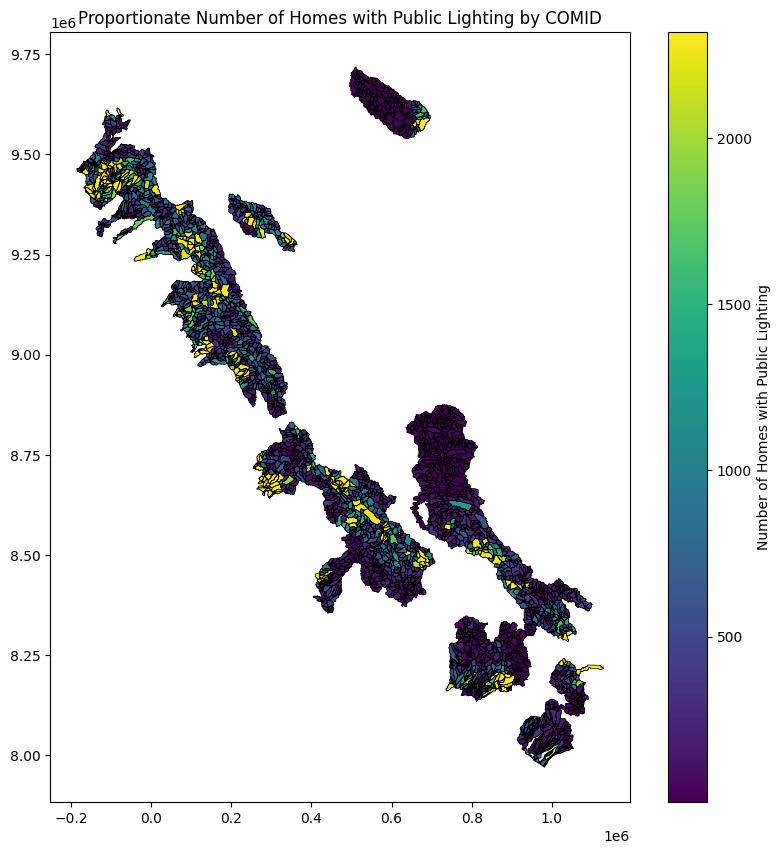

In [10]:
# plot the proportionate number of homes with public lighting by COMID
values = subbasins_gdf['proportionate_indicator_value']
vmin = np.nanpercentile(values, 5)
vmax = np.nanpercentile(values, 95)

fig, ax = plt.subplots(figsize=(10, 10))
subbasins_gdf.plot(
    column='proportionate_indicator_value',
    ax=ax,
    cmap='viridis',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label':'Number of Homes with Public Lighting'},
    vmin=vmin,
    vmax=vmax  # limits the color scale
)
plt.title('Proportionate Number of Homes with Public Lighting by COMID')
plt.show()

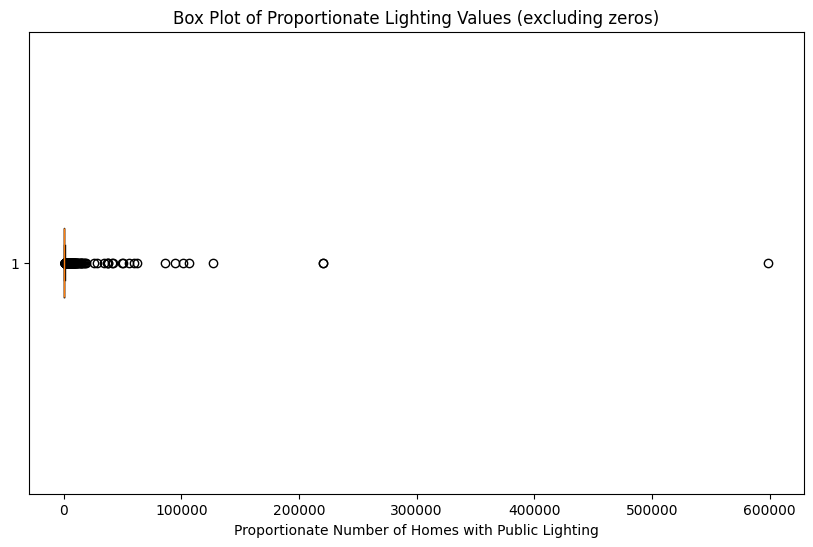

In [11]:
# Box plot to show quartiles and outliers
plt.figure(figsize=(10,6))
non_zero_values = subbasins_gdf[
    subbasins_gdf['proportionate_indicator_value'] > 0
]['proportionate_indicator_value']

plt.boxplot(non_zero_values, vert=False)
plt.xlabel('Proportionate Number of Homes with Public Lighting')
plt.title('Box Plot of Proportionate Lighting Values (excluding zeros)')
plt.show()

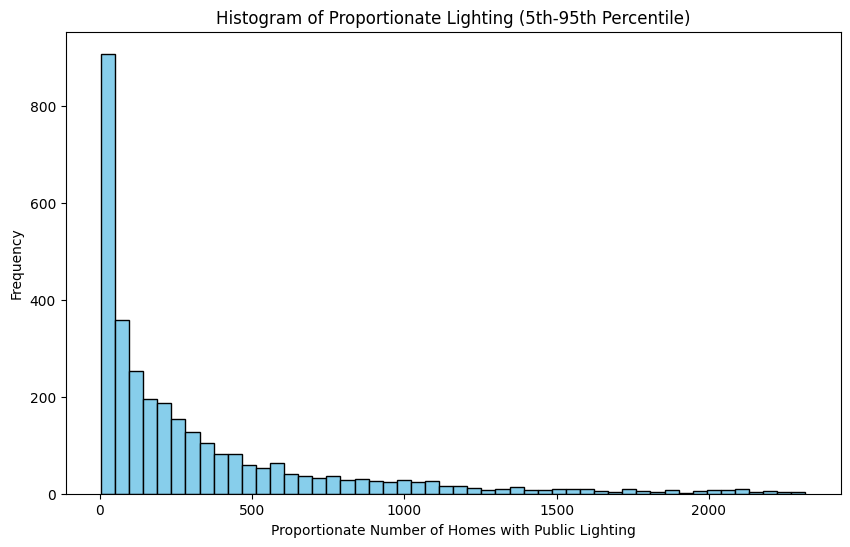

5th percentile: 3.00
95th percentile: 2317.65
Values in range: 3165 out of 3508


In [12]:
# Remove extreme outliers (top and bottom 5%)
lower_bound = non_zero_values.quantile(0.05)
upper_bound = non_zero_values.quantile(0.95)
trimmed_values = non_zero_values[
    (non_zero_values >= lower_bound) & (non_zero_values <= upper_bound)
]

plt.figure(figsize=(10,6))
plt.hist(trimmed_values, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Proportionate Lighting (5th-95th Percentile)')
plt.xlabel('Proportionate Number of Homes with Public Lighting')
plt.ylabel('Frequency')
plt.show()

print(f"5th percentile: {lower_bound:.2f}")
print(f"95th percentile: {upper_bound:.2f}")
print(f"Values in range: {len(trimmed_values)} out of {len(non_zero_values)}")

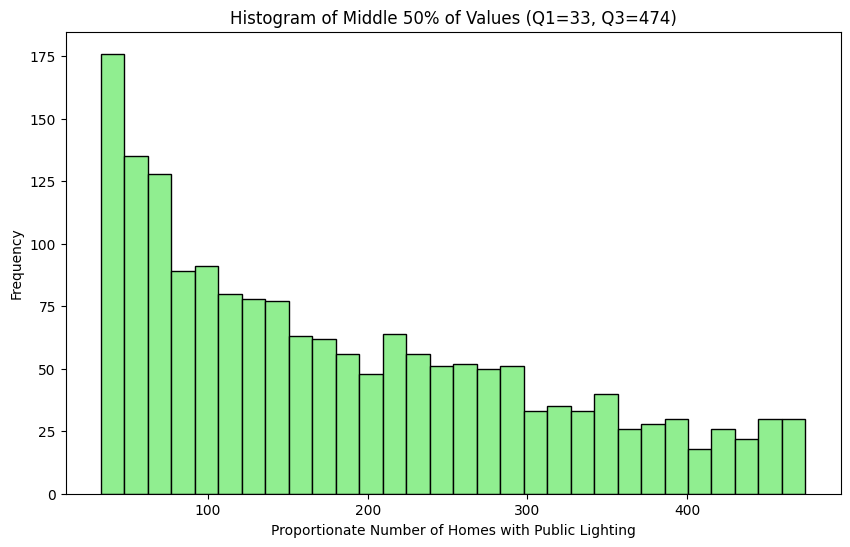

Q1 (25th percentile): 33.00
Q3 (75th percentile): 474.00
IQR: 441.00


In [13]:
# Calculate IQR and plot only middle 50%
Q1 = non_zero_values.quantile(0.25)
Q3 = non_zero_values.quantile(0.75)
IQR = Q3 - Q1

middle_50 = non_zero_values[(non_zero_values >= Q1) & (non_zero_values <= Q3)]

plt.figure(figsize=(10,6))
plt.hist(middle_50, bins=30, color='lightgreen', edgecolor='black')
plt.title(f'Histogram of Middle 50% of Values (Q1={Q1:.0f}, Q3={Q3:.0f})')
plt.xlabel('Proportionate Number of Homes with Public Lighting')
plt.ylabel('Frequency')
plt.show()

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

In [14]:
# insert results into the database 
insert_data= subbasins_gdf #COMID 
value_column= 'proportionate_indicator_value' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [15]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['proportionate_indicator_value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 208  Min: 0, Max: 700000

=== Values to be inserted (by scenario) ===
   index  proportionate_indicator_value
0    min                            1.0
1    max                       599025.0
2  count                         3508.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [16]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()